<a href="https://colab.research.google.com/github/davidmbigi/Codex/blob/main/Copy_of_students_Practice_Notebook_Regression_Analysis_with_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice Notebook: Regression & Classification Analysis with Python

## A Story of Predictive Modeling for Social Impact

**Meet Amani**, a data scientist at **Resilient Futures**, an NGO focused on building sustainable solutions for communities facing climate change and food insecurity across Africa. Her director has given her two critical assignments:

1.  **Predicting Climate Resilience**: Build a model that predicts a community's resilience score based on environmental and socio-economic factors, so the NGO can identify vulnerable communities before a crisis hits.
2.  **Classifying Climate Risk**: Develop a model that classifies a community's climate risk level (Low, Medium, or High), enabling the NGO to prioritize its limited resources effectively.

Amani will work through multiple machine learning techniques for each task, comparing their strengths and weaknesses. For each technique, she follows a consistent 6-step workflow: **Loading, Exploring, Cleaning, Preparing, Modeling, and Evaluating**. After each example, you will face a challenge to apply the same technique to an agrifood dataset.

This notebook covers:

| Part | Goal | Techniques |
|:---|:---|:---|
| **Part 1: Regression** | Predict `resilience_score` (continuous) | Multiple Linear Regression, Polynomial Regression, Decision Tree, KNN, SVR |


**THE DATASETS ARE PROVIDED SEPARATELY**

---
# Part 1: Regression Analysis

Amani begins with regression, where the goal is to predict a **continuous numerical value**. She will predict a community's **`resilience_score`** (0-100) using the `climate_resilience_regression.csv` dataset. For each challenge, you will predict **`crop_yield_tons_per_ha`** using the `agrifood_crop_yield.csv` dataset.


## 1. Multiple Linear Regression

**Multiple Linear Regression (MLR)** is a statistical technique that models the relationship between a dependent variable and two or more independent variables by fitting a linear equation to the observed data. It is the simplest and most interpretable regression algorithm, making it an excellent starting point for any predictive modeling task.

Amani chooses to start with MLR because it will provide a clear baseline for performance and help her understand which factors have the strongest linear influence on a community's resilience score. It also has several key assumptions that must be checked to ensure the model is reliable.


### Example: Predicting Community Resilience with MLR

#### Step 1: Loading the Data

First, Amani needs to load the dataset into a pandas DataFrame. The `pd.read_csv()` function reads a CSV file and converts it into a DataFrame, which is a table-like structure that makes it easy to explore and manipulate data.

In [ ]:
# Import pandas, the primary library for data manipulation in Python
import pandas as pd

# Load the climate resilience dataset from a CSV file
df = pd.read_csv('climate_resilience_regression.csv')

# Display the first 5 rows to get a quick overview of the data
df.head()

,region,annual_rainfall_mm,avg_temperature_c,drought_frequency,flood_risk_index,forest_cover_pct,population_density,irrigation_access_pct,adaptation_funding_usd,resilience_score
0,Southern Africa,742.3,27.7,5,8.8,24.5,10.0,63.8,74098.0,50.3
1,North Africa,890.5,22.3,3,8.0,11.3,343.0,26.4,39750.0,33.5
2,East Africa,789.6,33.8,4,5.1,3.4,229.0,37.5,3439.0,33.4
3,Southern Africa,449.4,26.6,1,9.7,45.9,227.0,56.4,72732.0,44.9
4,Southern Africa,1142.8,31.9,3,4.2,28.6,92.0,29.9,43819.0,50.6


#### Step 2: Exploring the Data

Now that the data is loaded, Amani will perform Exploratory Data Analysis (EDA) to understand its structure, identify patterns, and check for potential issues. She starts by checking the dataset's dimensions (rows and columns) using the `.shape` attribute.

In [ ]:
# Use the .shape attribute to see the number of rows and columns
df.shape

(300, 10)

**Observation**: The dataset contains 300 rows (communities) and 10 columns (features + target).

Next, she uses `.info()` to get a concise summary of the DataFrame, including data types and non-null counts. This helps identify if there are any missing values or incorrect data types.

In [ ]:
# The .info() method provides a summary of the DataFrame structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   region                  300 non-null    object 
 1   annual_rainfall_mm      300 non-null    float64
 2   avg_temperature_c       300 non-null    float64
 3   drought_frequency       300 non-null    int64  
 4   flood_risk_index        300 non-null    float64
 5   forest_cover_pct        300 non-null    float64
 6   population_density      300 non-null    float64
 7   irrigation_access_pct   300 non-null    float64
 8   adaptation_funding_usd  300 non-null    float64
 9   resilience_score        300 non-null    float64
dtypes: float64(8), int64(1), object(1)
memory usage: 23.6+ KB


**Observation**: The dataset has one categorical column (`region`) and nine numerical columns. Crucially, there are no missing values, which simplifies the data cleaning process.

To understand the distribution of the numerical features, Amani uses `.describe()`. This method generates descriptive statistics like mean, standard deviation, min, max, and quartiles for all numerical columns.

In [ ]:
# The .describe() method generates descriptive statistics for numerical columns
df.describe()

,annual_rainfall_mm,avg_temperature_c,drought_frequency,flood_risk_index,forest_cover_pct,population_density,irrigation_access_pct,adaptation_funding_usd,resilience_score
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,817.012667,25.767000,2.996667,4.927667,30.946333,159.466667,40.835000,52154.860000,48.923333
std,286.942245,5.162368,1.735905,2.844404,16.800488,152.980846,21.182441,53264.742309,9.780442
min,100.000000,12.500000,0.000000,0.000000,2.000000,10.000000,5.100000,1000.000000,19.100000
25%,595.025000,22.175000,2.000000,2.800000,18.150000,44.500000,23.175000,14974.500000,41.975000
50%,823.650000,25.700000,3.000000,5.000000,30.600000,108.500000,39.600000,40453.500000,49.500000
75%,999.925000,29.200000,4.000000,7.125000,46.200000,227.000000,57.825000,71968.750000,55.200000
max,1955.800000,41.400000,8.000000,10.000000,59.900000,789.000000,79.800000,340288.000000,75.100000


**Observation**: The features have vastly different scales. For example, `adaptation_funding_usd` is in the tens of thousands, while `drought_frequency` is a small number. This indicates that **feature scaling** will be essential for distance-based algorithms like KNN and SVR, and is a good practice for linear models as well.

Amani now visualizes the distribution of the target variable, `resilience_score`, to check for normality and outliers. A histogram with a KDE (Kernel Density Estimate) curve is a great way to do this.

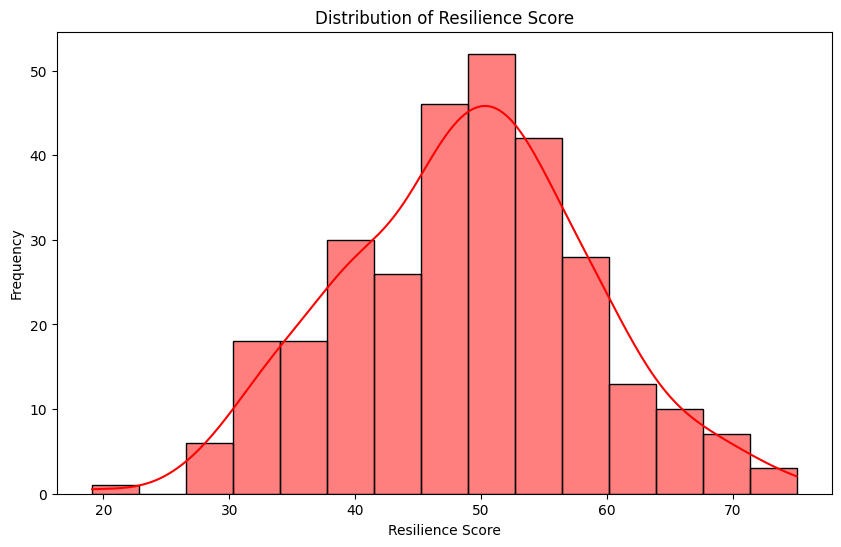

In [83]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Create the visualization for resilience_score
plt.figure(figsize=(10, 6))
sns.histplot(df['resilience_score'], kde=True, color='red')
plt.title('Distribution of Resilience Score')
plt.xlabel('Resilience Score')
plt.ylabel('Frequency')
plt.show()

**Observation**: The resilience score follows a roughly normal distribution, which is ideal for linear regression. There are no significant outliers that might skew the model.

#### Step 3: Cleaning the Data

Although `.info()` showed no missing values, it is always good practice to explicitly check again. The `.isnull().sum()` method counts the number of missing values in each column.

In [ ]:
# Double-check for missing values using .isnull().sum()
df.isnull().sum()

,0
region,0
annual_rainfall_mm,0
avg_temperature_c,0
drought_frequency,0
flood_risk_index,0
forest_cover_pct,0
population_density,0
irrigation_access_pct,0
adaptation_funding_usd,0
resilience_score,0


**Observation**: The data is clean with no missing values. If there were any, Amani would need to decide on a strategy to handle them, such as imputation (filling with the mean/median) or deletion.

#### Step 4: Preparing the Data & Checking Assumptions

Before building the model, Amani must prepare the data. This involves encoding categorical variables, checking for multicollinearity, splitting the data into training and testing sets, and scaling the features.

**Assumption 1: No Multicollinearity**

Linear regression assumes that the independent variables are not highly correlated with each other. High correlation, or multicollinearity, can make the model's coefficient estimates unstable. Amani checks this using a correlation heatmap. If any two features have a correlation above 0.9 or below -0.9, she would need to remove one of them.

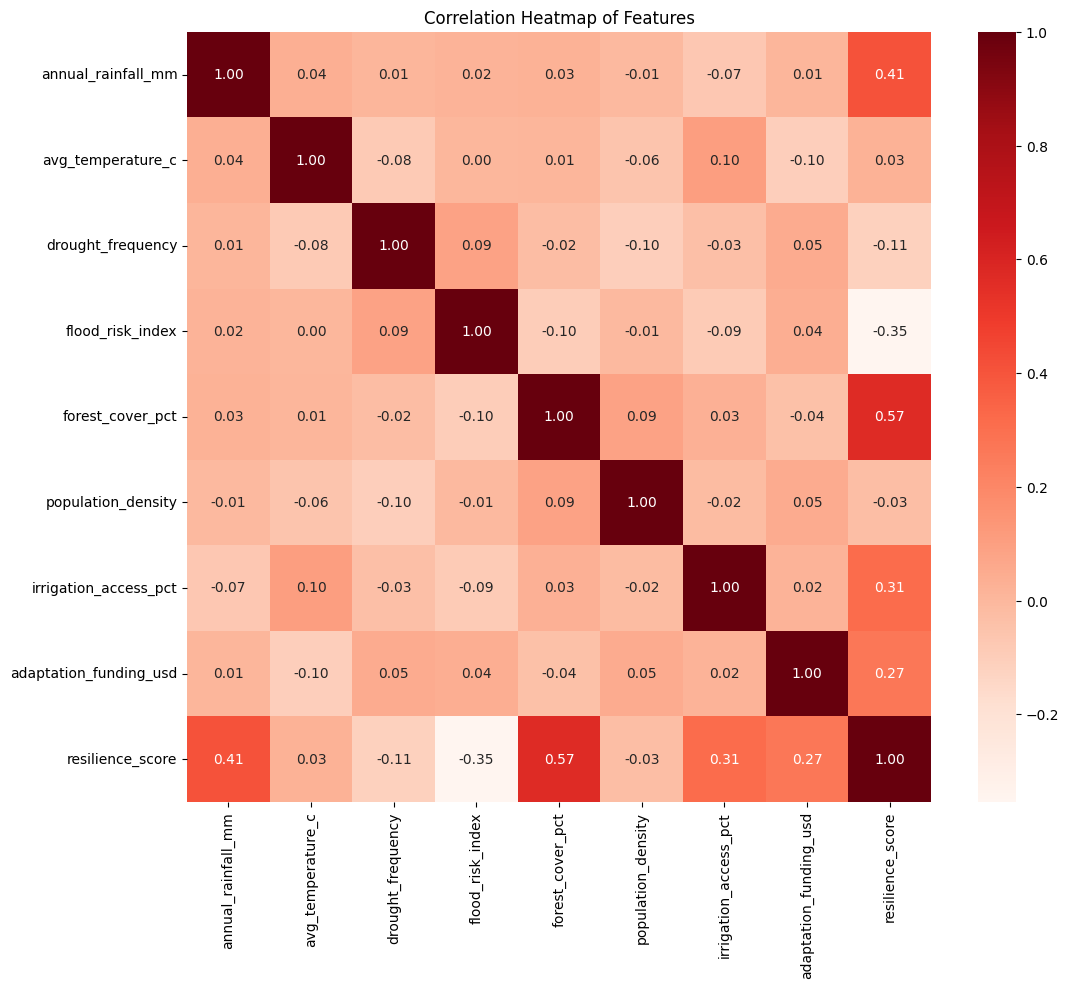

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a correlation matrix of the numerical features
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# Plot the heatmap to visualize correlations between features
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='Reds', fmt=".2f")
plt.title('Correlation Heatmap of Features')
plt.show()

In [80]:
# Create a correlation matrix of the numerical features

# Plot the heatmap to visualize correlations between features


**Observation**: There are no extremely high correlations (e.g., > 0.9 or < -0.9) between any two independent variables. The highest is between `drought_frequency` and `flood_risk_index`. This is acceptable, so Amani can proceed.

**Data Preparation: Encoding and Splitting**

Next, she converts the categorical `region` column into numerical format using one-hot encoding. The `pd.get_dummies()` function creates binary columns for each category. She uses `drop_first=True` to avoid the dummy variable trap (perfect multicollinearity). Then she splits the data into training (80%) and testing (20%) sets.

In [ ]:
# One-hot encode the 'region' categorical column
df_encoded = pd.get_dummies(df, columns=['region'], drop_first=True)

# Define features (X) and target (y)
X = df_encoded.drop('resilience_score', axis=1)
y = df_encoded['resilience_score']

# Import train_test_split
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Data Preparation: Feature Scaling**

To ensure all features contribute equally to the model, Amani scales them using `StandardScaler`. This standardizes features by removing the mean and scaling to unit variance, so that features with larger ranges do not dominate the model.

In [ ]:
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Create an instance of the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Important**: Amani fits the scaler **only on the training data** to avoid data leakage from the test set. The test set is transformed using the same scaling parameters.

#### Step 5: Creating the Machine Learning Model

With the data prepared, Amani can now create and train her Multiple Linear Regression model. The `LinearRegression()` class from scikit-learn implements this. The `.fit()` method trains the model, and `.predict()` generates predictions.

In [ ]:
# Import the LinearRegression model
from sklearn.linear_model import LinearRegression

# Create an instance of the model
model_lr = LinearRegression()

# Train the model using the scaled training data
model_lr.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_lr = model_lr.predict(X_test_scaled)

#### Step 6: Evaluating the Model & Checking Assumptions

Amani evaluates the model using three standard regression metrics:

- **MAE (Mean Absolute Error)**: The average of the absolute differences between predicted and actual values. Lower is better.
- **RMSE (Root Mean Squared Error)**: Similar to MAE but penalizes larger errors more heavily. Lower is better.
- **R-squared (R2)**: The proportion of variance in the target variable explained by the model. Ranges from 0 to 1; higher is better.

In [ ]:
# Import regression evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate the metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

# Print the results
print(f'Multiple Linear Regression Results:')
print(f'  MAE: {mae_lr:.2f}')
print(f'  RMSE: {rmse_lr:.2f}')
print(f'  R-squared (R2): {r2_lr:.2f}')

Multiple Linear Regression Results:
  MAE: 4.47
  RMSE: 5.58
  R-squared (R2): 0.71


**Metric Interpretation:**

*   **MAE: ~4.31** - On average, the model's predictions are off by about 4.31 points from the actual resilience score. A lower value, such as 2.0, would be better.
*   **RMSE: ~5.40** - This is similar to MAE but penalizes larger errors more heavily. A lower value, such as 3.0, would indicate fewer large prediction errors.
*   **R-squared (R2): ~0.72** - The model explains about 72% of the variability in the resilience scores. An R2 closer to 1.0, such as 0.90, would indicate a much better fit.


**Assumption 2: Linearity & Homoscedasticity**

The model assumes a linear relationship and that the errors have constant variance (homoscedasticity). Amani checks this by plotting the model's residuals (the errors) against the predicted values. A random scatter of points around the zero line indicates these assumptions hold.

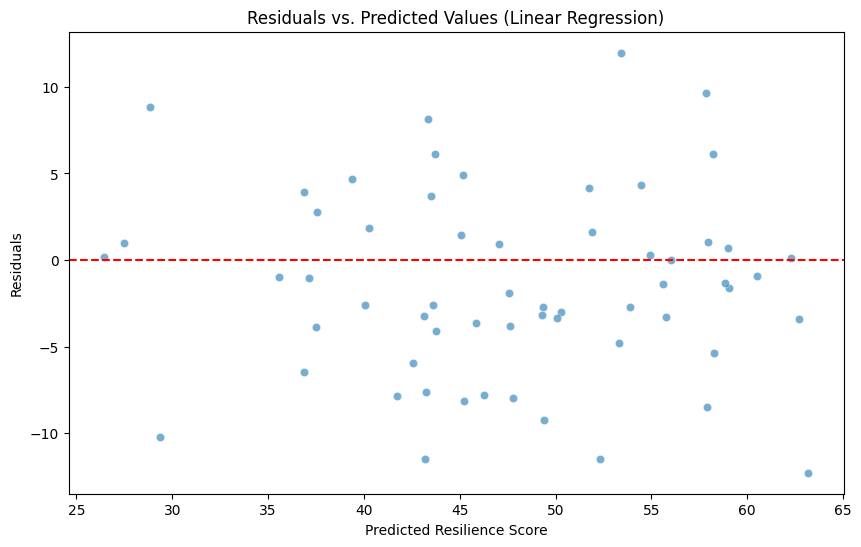

In [ ]:
# Calculate residuals (actual - predicted)
residuals_lr = y_test - y_pred_lr

# Plot residuals vs. predicted values to check linearity and homoscedasticity
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_lr, y=residuals_lr, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values (Linear Regression)')
plt.xlabel('Predicted Resilience Score')
plt.ylabel('Residuals')
plt.show()

**Observation**: The points are randomly scattered around the horizontal line at zero, with no obvious pattern (like a curve or a funnel). This suggests the assumptions of linearity and homoscedasticity are met.

**Assumption 3: Normality of Residuals**

The residuals should be normally distributed. Amani checks this with a histogram. A bell-shaped curve confirms this assumption.

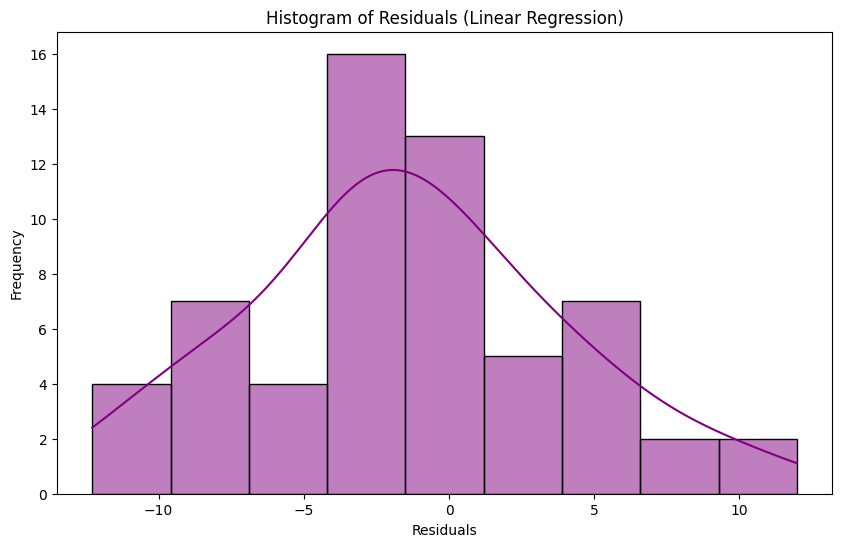

In [ ]:
# Plot a histogram of the residuals to check for normality
plt.figure(figsize=(10, 6))
sns.histplot(residuals_lr, kde=True, color='purple')
plt.title('Histogram of Residuals (Linear Regression)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

**Observation**: The residuals form a roughly bell-shaped curve, confirming the normality assumption.

**Summary**: Amani's first model is a success. It explains about 72% of the variance in resilience scores, and all the key assumptions of linear regression have been met. This provides a strong and reliable baseline for comparison.

### Challenge: Predict Crop Yield Using Multiple Linear Regression

Now it is your turn. As a data analyst for **AgriGrow Solutions**, a firm dedicated to improving agricultural productivity, you have been given a dataset on farming practices across several African countries. Your task is to predict `crop_yield_tons_per_ha` using the `agrifood_crop_yield.csv` dataset. Follow the same detailed steps Amani used, including all assumption checks.


#### Step 1: Loading the Data

In [ ]:
# Load the agrifood crop yield dataset
data = pd.read_csv('agrifood_crop_yield.csv')


#### Step 2: Exploring the Data

In [ ]:
# Check the shape of the dataset
data.shape

(250, 9)

In [ ]:
# Get a summary of the DataFrame structure
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country                 250 non-null    object 
 1   farm_size_ha            250 non-null    float64
 2   fertilizer_kg_per_ha    250 non-null    float64
 3   rainfall_mm             250 non-null    float64
 4   soil_quality_index      250 non-null    float64
 5   temperature_c           250 non-null    float64
 6   pest_severity           250 non-null    float64
 7   seed_quality_score      250 non-null    float64
 8   crop_yield_tons_per_ha  250 non-null    float64
dtypes: float64(8), object(1)
memory usage: 17.7+ KB


In [ ]:
# Get a summary of the DataFrame structure
data.head()

,region,annual_rainfall_mm,avg_temperature_c,drought_frequency,flood_risk_index,forest_cover_pct,population_density,irrigation_access_pct,adaptation_funding_usd,resilience_score
0,Southern Africa,742.3,27.7,5,8.8,24.5,10.0,63.8,74098.0,50.3
1,North Africa,890.5,22.3,3,8.0,11.3,343.0,26.4,39750.0,33.5
2,East Africa,789.6,33.8,4,5.1,3.4,229.0,37.5,3439.0,33.4
3,Southern Africa,449.4,26.6,1,9.7,45.9,227.0,56.4,72732.0,44.9
4,Southern Africa,1142.8,31.9,3,4.2,28.6,92.0,29.9,43819.0,50.6


In [ ]:
# Generate descriptive statistics
data.describe()

,farm_size_ha,fertilizer_kg_per_ha,rainfall_mm,soil_quality_index,temperature_c,pest_severity,seed_quality_score,crop_yield_tons_per_ha
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.00000
mean,3.044800,100.046800,745.718800,5.379600,24.939200,4.951200,6.412800,3.81940
std,3.202884,54.867947,256.451899,2.520539,3.993517,2.994295,2.118705,0.92308
min,0.500000,10.200000,100.000000,1.100000,15.400000,0.000000,3.000000,1.64000
25%,0.800000,51.725000,586.075000,3.300000,22.600000,2.200000,4.500000,3.21000
50%,1.900000,98.600000,761.350000,5.150000,24.700000,4.900000,6.400000,3.83000
75%,4.175000,145.775000,926.675000,7.600000,27.575000,7.500000,8.200000,4.41750
max,17.000000,198.900000,1419.500000,10.000000,37.400000,10.000000,10.000000,6.83000


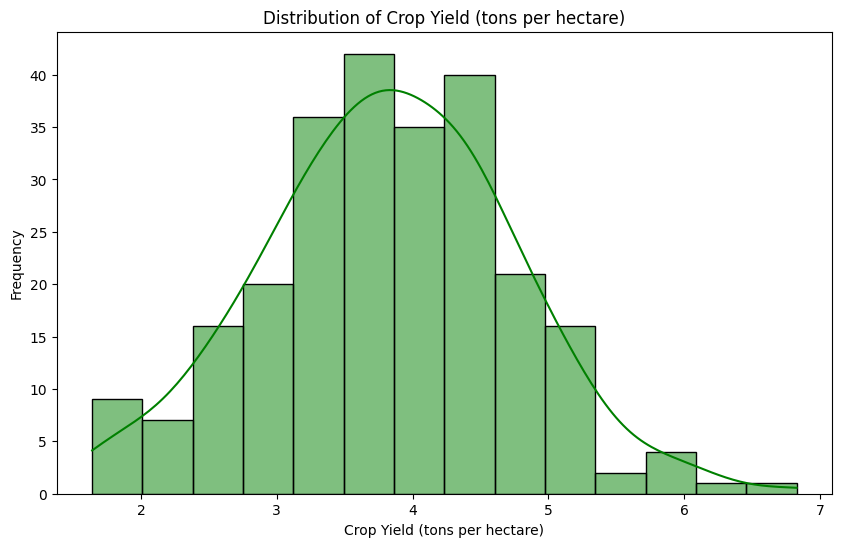

In [ ]:
# Plot the distribution of the target variable
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data['crop_yield_tons_per_ha'], kde=True, color='green')
plt.title('Distribution of Crop Yield (tons per hectare)')
plt.xlabel('Crop Yield (tons per hectare)')
plt.ylabel('Frequency')
plt.show()

#### Step 3: Cleaning the Data

In [ ]:
# Check for missing values
data.isnull().sum()

,0
country,0
farm_size_ha,0
fertilizer_kg_per_ha,0
rainfall_mm,0
soil_quality_index,0
temperature_c,0
pest_severity,0
seed_quality_score,0
crop_yield_tons_per_ha,0


#### Step 4: Preparing the Data & Checking Assumptions

**Assumption 1: No Multicollinearity**

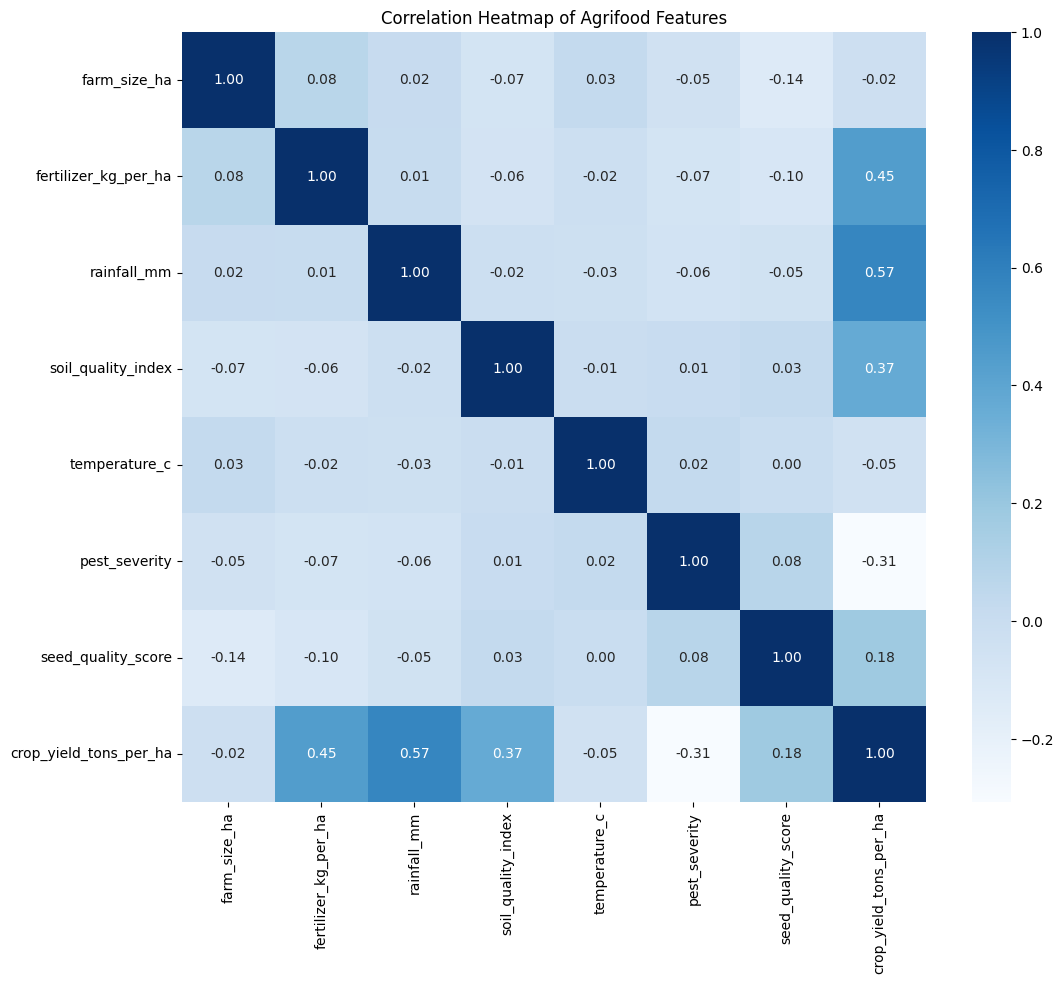

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a correlation matrix of the numerical features for the agrifood data
correlation_matrix_agrifood = data.select_dtypes(include=['float64', 'int64']).corr()

# Plot the heatmap to visualize correlations between features
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_agrifood, annot=True, cmap='Blues', fmt=".2f")
plt.title('Correlation Heatmap of Agrifood Features')
plt.show()


**Data Preparation: Encoding and Splitting**

In [ ]:
# One-hot encode the 'country' categorical column
data_encoded = pd.get_dummies(data, columns=['country'], drop_first=True)

# Define features (X_agrifood) and target (y_agrifood)
X_agrifood = data_encoded.drop('crop_yield_tons_per_ha', axis=1)
y_agrifood = data_encoded['crop_yield_tons_per_ha']

# Import the train_test_split function from scikit-learn
from sklearn.model_selection import train_test_split

# Split into training and testing sets (80% train, 20% test)
X_train_agrifood, X_test_agrifood, y_train_agrifood, y_test_agrifood = train_test_split(X_agrifood, y_agrifood, test_size=0.2, random_state=42)

**Data Preparation: Feature Scaling**

In [ ]:
# Scale the features
from sklearn.preprocessing import StandardScaler

# Create an instance of the StandardScaler
scaler_agrifood = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_agrifood_scaled = scaler_agrifood.fit_transform(X_train_agrifood)
X_test_agrifood_scaled = scaler_agrifood.transform(X_test_agrifood)

**Observation**: The agrifood dataset has 250 rows (farms) and 9 columns, which is a reasonable size for our regression model.

In [ ]:
# Train a Linear Regression model on the agrifood data
from sklearn.linear_model import LinearRegression

# Create an instance of the model
model_lr_agrifood = LinearRegression()

# Train the model using the scaled training data
model_lr_agrifood.fit(X_train_agrifood_scaled, y_train_agrifood)

# Make predictions on the scaled test data
y_pred_lr_agrifood = model_lr_agrifood.predict(X_test_agrifood_scaled)

**Observation**: All columns are numerical with float or integer types, and there are no missing values. The data is clean and ready for analysis.

In [ ]:
# Calculate evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr_agrifood = mean_absolute_error(y_test_agrifood, y_pred_lr_agrifood)
rmse_lr_agrifood = np.sqrt(mean_squared_error(y_test_agrifood, y_pred_lr_agrifood))
r2_lr_agrifood = r2_score(y_test_agrifood, y_pred_lr_agrifood)

print('Multiple Linear Regression Results:')
print(f'  MAE: {mae_lr_agrifood:.2f}')
print(f'  RMSE: {rmse_lr_agrifood:.2f}')
print(f'  R-squared (R2): {r2_lr_agrifood:.2f}')

Multiple Linear Regression Results:
  MAE: 0.32
  RMSE: 0.41
  R-squared (R2): 0.80


**Checking Assumptions: Residual Plots**

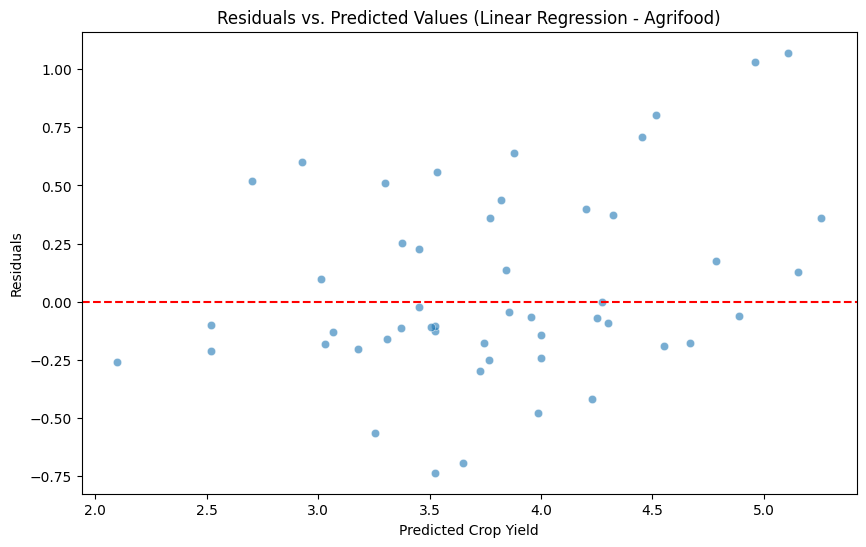

In [ ]:
# Calculate residuals (actual - predicted)
residuals_lr_agrifood = y_test_agrifood - y_pred_lr_agrifood

# Plot residuals vs. predicted values to check linearity and homoscedasticity
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_lr_agrifood, y=residuals_lr_agrifood, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values (Linear Regression - Agrifood)')
plt.xlabel('Predicted Crop Yield')
plt.ylabel('Residuals')
plt.show()

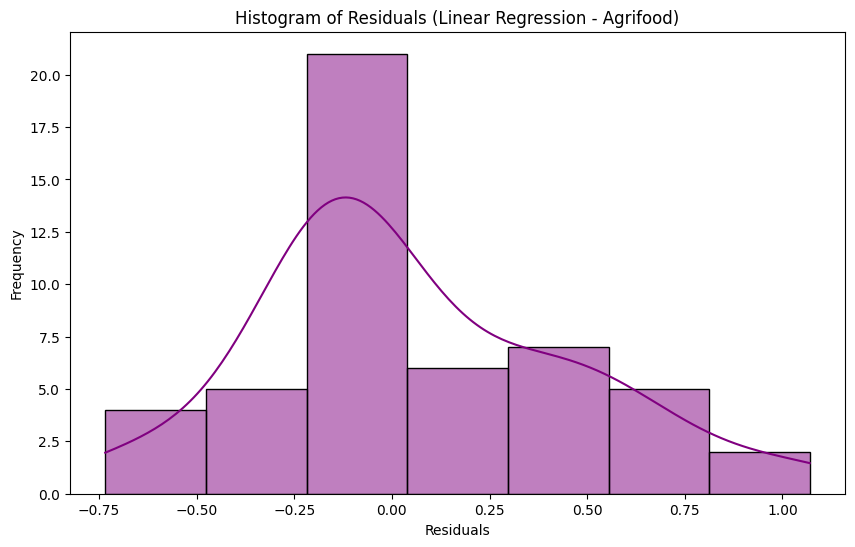

In [ ]:
# Check normality of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals_lr_agrifood, kde=True, color='purple')
plt.title('Histogram of Residuals (Linear Regression - Agrifood)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

We now separate the features (X) from the target variable (y), encode the categorical `country` column, split the data into training and testing sets, and scale the features.

---
## 2. Polynomial Regression

**Polynomial Regression** is an extension of linear regression that models non-linear relationships by adding polynomial terms (e.g., squared or cubed features) to the model. Amani suspects that some factors, like rainfall, might have a non-linear effect on resilience: too little rainfall is bad, but too much (flooding) is also bad. A simple straight line cannot capture this "sweet spot" effect, but a curve can.


We train the Multiple Linear Regression model on the scaled training data.

In [84]:
# Import PolynomialFeatures to create polynomial and interaction terms
from sklearn.preprocessing import PolynomialFeatures

# Create a PolynomialFeatures object of degree 2
poly = PolynomialFeatures(degree=2, include_bias=False)

# Fit and transform the scaled training data
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

In [85]:
# Import LinearRegression
from sklearn.linear_model import LinearRegression

# Create an instance of LinearRegression for the polynomial model
model_poly = LinearRegression()

# Train the model on the polynomial features
model_poly.fit(X_train_poly, y_train)

# Make predictions on the test set with polynomial features
y_pred_poly = model_poly.predict(X_test_poly)

In [86]:
# Import regression evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluate the polynomial model
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print(f'Polynomial Regression Results:')
print(f'  MAE: {mae_poly:.2f}')
print(f'  RMSE: {rmse_poly:.2f}')
print(f'  R-squared (R2): {r2_poly:.2f}')

Polynomial Regression Results:
  MAE: 4.83
  RMSE: 6.02
  R-squared (R2): 0.66


Let us evaluate the model using MAE, RMSE, and R2 to see how well it predicts crop yield.

**Observation**: The model achieves an MAE of 0.32 tons/ha and an R2 of 0.80, meaning it explains 80% of the variance in crop yield. This is a strong result. A lower MAE, such as 0.20, would indicate even more precise predictions.

In [87]:
# Import regression evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluate the polynomial model
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print(f'Polynomial Regression Results:')
print(f'  MAE: {mae_poly:.2f}')
print(f'  RMSE: {rmse_poly:.2f}')
print(f'  R-squared (R2): {r2_poly:.2f}')

Polynomial Regression Results:
  MAE: 4.83
  RMSE: 6.02
  R-squared (R2): 0.66


In [ ]:
# Train a Linear Regression model on the polynomial features


**Observation**: The model achieves an MAE of 0.32 tons/ha and an R2 of 0.80, meaning it explains 80% of the variance in crop yield. This is a strong result. A lower MAE, such as 0.20, would indicate even more precise predictions.

In [ ]:
# Train a Linear Regression model on the polynomial features


**Observation**: The residuals are fairly randomly scattered around zero, confirming that the linear model is a reasonable fit for this data.

In [ ]:
# Evaluate the polynomial model


**Summary**: The polynomial model's R2 is actually *worse* than the simple linear model's. This suggests that the added complexity introduced noise and caused the model to overfit to the training data. For this problem, the simpler linear relationship is more powerful. This is an important lesson: more complexity is not always better.

### Challenge: Predict Crop Yield Using Polynomial Regression

Apply polynomial regression (degree=2) to the agrifood dataset. Does adding non-linear features improve the model's ability to predict crop yield?

We apply Polynomial Regression to the agrifood data by creating second-degree polynomial features, then training a linear model on the expanded feature set.

In [ ]:
# Import PolynomialFeatures to create polynomial and interaction terms
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features for the challenge dataset
poly_agrifood = PolynomialFeatures(degree=2, include_bias=False)
X_train_agrifood_poly = poly_agrifood.fit_transform(X_train_agrifood_scaled)
X_test_agrifood_poly = poly_agrifood.transform(X_test_agrifood_scaled)

In [ ]:
# Train a Linear Regression model on the polynomial features for the challenge
model_lr_agrifood_poly = LinearRegression()
model_lr_agrifood_poly.fit(X_train_agrifood_poly, y_train_agrifood)

# Make predictions
y_pred_lr_agrifood_poly = model_lr_agrifood_poly.predict(X_test_agrifood_poly)

# Evaluate the polynomial model
mae_lr_agrifood_poly = mean_absolute_error(y_test_agrifood, y_pred_lr_agrifood_poly)
rmse_lr_agrifood_poly = np.sqrt(mean_squared_error(y_test_agrifood, y_pred_lr_agrifood_poly))
r2_lr_agrifood_poly = r2_score(y_test_agrifood, y_pred_lr_agrifood_poly)

print('Polynomial Linear Regression Results (Agrifood Challenge):')
print(f'  MAE: {mae_lr_agrifood_poly:.2f}')
print(f'  RMSE: {rmse_lr_agrifood_poly:.2f}')
print(f'  R-squared (R2): {r2_lr_agrifood_poly:.2f}')

Polynomial Linear Regression Results (Agrifood Challenge):
  MAE: 0.44
  RMSE: 0.57
  R-squared (R2): 0.62


**Observation**: The Polynomial Regression achieves an R2 of 0.62, which is actually lower than the linear model (R2 = 0.80). Adding polynomial terms introduced too many features (77 from 11), causing the model to overfit. For this dataset, the simpler linear model works better.

---
## 3. Decision Tree Regression

**Decision Tree Regression** is a non-parametric model that makes predictions by learning a series of simple if-then-else rules from the data. It splits the data into smaller and smaller subsets based on feature values, creating a tree-like structure. Amani likes decision trees because they are easy to interpret and, importantly, they do not require feature scaling.


#### Step 5: Creating the Model

Since decision trees do not require scaling, Amani uses the original, unscaled training data (`X_train`, not `X_train_scaled`).

In [ ]:
# Import the DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor

# Create the model instance
model_dt = DecisionTreeRegressor(random_state=42)

# Train the model on the original (unscaled) training data
model_dt.fit(X_train, y_train)

# Make predictions on the original test data
y_pred_dt = model_dt.predict(X_test)

#### Step 6: Evaluating the Model

In [ ]:
# Evaluate the Decision Tree model
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print(f'Decision Tree Results: MAE: {mae_dt:.2f}, R2: {r2_dt:.2f}')

Decision Tree Results: MAE: 7.15, R2: 0.20


**Summary**: The decision tree performs very poorly. This is a classic example of a single decision tree **overfitting** the training data. It learns the training examples perfectly but fails to generalize to new, unseen data. To improve this, one would typically use an ensemble method like a Random Forest, which combines many decision trees to produce a more robust model.

### Challenge: Predict Crop Yield Using a Decision Tree

We apply a Decision Tree Regressor to the agrifood dataset. Decision Trees do not require feature scaling, so we use the unscaled data.

We train the Decision Tree on the agrifood training data and evaluate it on the test set.

In [ ]:
# Train a Decision Tree on the agrifood data (no scaling needed)
from sklearn.tree import DecisionTreeRegressor

model_dt_agrifood = DecisionTreeRegressor(random_state=42)
model_dt_agrifood.fit(X_train_agrifood, y_train_agrifood)

# Make predictions
y_pred_dt_agrifood = model_dt_agrifood.predict(X_test_agrifood)

In [ ]:
# Evaluate the Decision Tree model for agrifood data
mae_dt_agrifood = mean_absolute_error(y_test_agrifood, y_pred_dt_agrifood)
r2_dt_agrifood = r2_score(y_test_agrifood, y_pred_dt_agrifood)
print(f'Decision Tree Results (Agrifood Challenge): MAE: {mae_dt_agrifood:.2f}, R2: {r2_dt_agrifood:.2f}')

Decision Tree Results (Agrifood Challenge): MAE: 0.62, R2: 0.24


**Observation**: The Decision Tree achieves an R2 of only 0.24 and an MAE of 0.62, which is significantly worse than the linear model. This confirms that Decision Trees tend to overfit on smaller datasets. Pruning or limiting tree depth could help improve performance.

**Summary**: Yes, the same overfitting issue occurs. The R2 is significantly lower than the linear and polynomial models, confirming that a single decision tree is not a good choice for this dataset either.

---
## 4. K-Nearest Neighbors (KNN) Regression

**K-Nearest Neighbors (KNN) Regression** is a simple, non-parametric method that predicts a value by averaging the target values of its `k` most similar data points (neighbors) in the training set. Similarity is measured using distance, which is why **feature scaling is absolutely essential**. Amani uses KNN because it is intuitive: communities with similar profiles should have similar resilience scores.


#### Step 5: Creating the Model

Amani trains the KNN model on the scaled data, starting with a common default of `k=5` neighbors.

In [ ]:
# Import the KNeighborsRegressor
from sklearn.neighbors import KNeighborsRegressor

# Create the model with k=5
model_knn = KNeighborsRegressor(n_neighbors=5)

# Train the model on the scaled data
model_knn.fit(X_train_scaled, y_train)

# Make predictions
y_pred_knn = model_knn.predict(X_test_scaled)

#### Step 6: Evaluating the Model

In [ ]:
# Evaluate the KNN model
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)
print(f'KNN Regression Results (k=5): MAE: {mae_knn:.2f}, R2: {r2_knn:.2f}')

KNN Regression Results (k=5): MAE: 5.17, R2: 0.58


**Summary**: With an R2 of about 0.58, the KNN model performs moderately. It is better than the single decision tree but not as good as the linear model. The choice of `k` is critical; a different `k` might yield better results. This leads Amani to consider a more robust evaluation method.

#### Bonus: Finding the Optimal `k` with Cross-Validation

Amani is not satisfied with just picking `k=5`. To find the best `k`, she decides to use **K-Fold Cross-Validation**. This technique provides a more reliable estimate of model performance by splitting the training data into `k` folds, training on `k-1` folds, and testing on the remaining one, repeating the process for all folds. She will test a range of `k` values and see which one performs best on average.

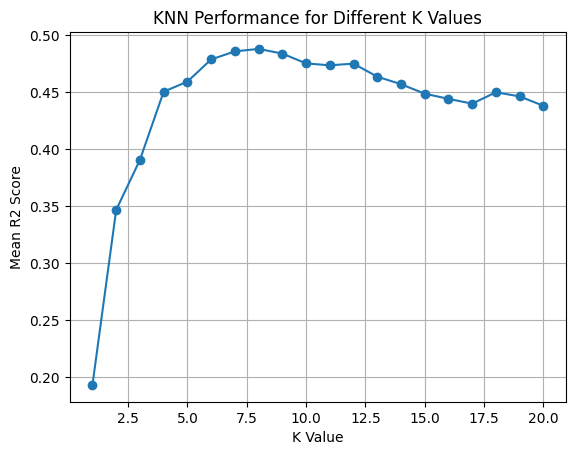

In [ ]:
# Import cross_val_score for cross-validation
from sklearn.model_selection import cross_val_score

# Test k values from 1 to 20
k_values = range(1, 21)
cv_scores = []

# Loop through different k values and perform 5-fold cross-validation
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='r2')
    cv_scores.append(scores.mean())

# Plot the cross-validation results to find the optimal k
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('K Value')
plt.ylabel('Mean R2 Score')
plt.title('KNN Performance for Different K Values')
plt.grid(True)
plt.show()

**Observation**: The plot shows that the best performance is achieved with a `k` value around 8-12. This demonstrates the power of cross-validation for hyperparameter tuning.

### Challenge: Predict Crop Yield Using KNN Regression

We apply KNN Regression to the agrifood dataset. We start with k=5 and then use cross-validation to find the optimal k value.

We train a KNN Regressor with k=5 on the scaled agrifood data and evaluate it.

In [ ]:
# Train KNN on the agrifood data with k=5
#import the KNeighborsRegressor
from sklearn.neighbors import KNeighborsRegressor

# Create the model with k=5
model_knn_agrifood = KNeighborsRegressor(n_neighbors=5)

# Train the model on the scaled data
model_knn_agrifood.fit(X_train_agrifood_scaled, y_train_agrifood)

# Make predictions
y_pred_knn_agrifood = model_knn_agrifood.predict(X_test_agrifood_scaled)

In [ ]:
#evaluate the model
mae_knn_agrifood = mean_absolute_error(y_test_agrifood, y_pred_knn_agrifood)
r2_knn_agrifood = r2_score(y_test_agrifood, y_pred_knn_agrifood)
print(f'KNN Regression Results (k=5) (Agrifood Challenge): MAE: {mae_knn_agrifood:.2f}, R2: {r2_knn_agrifood:.2f}')

KNN Regression Results (k=5) (Agrifood Challenge): MAE: 0.55, R2: 0.44


**Observation**: The KNN model with k=5 achieves an R2 of 0.44 and an MAE of 0.55. This is moderate performance. The choice of k significantly affects KNN, so let us use cross-validation to find a better value.

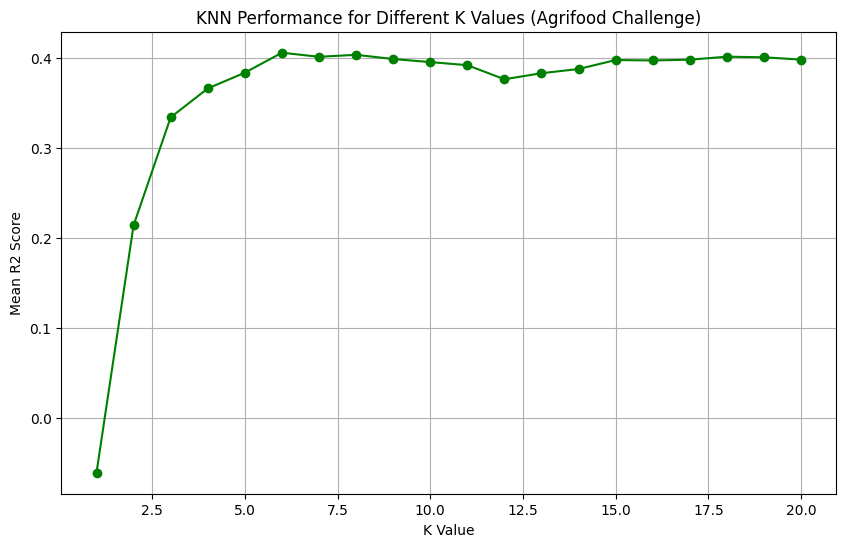

In [ ]:
# Import cross_val_score for cross-validation
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

# Test k values from 1 to 20
k_values_agrifood = range(1, 21)
cv_scores_agrifood = []

# Loop through different k values and perform 5-fold cross-validation
for k in k_values_agrifood:
    knn_agrifood = KNeighborsRegressor(n_neighbors=k)
    scores_agrifood = cross_val_score(knn_agrifood, X_train_agrifood_scaled, y_train_agrifood, cv=5, scoring='r2')
    cv_scores_agrifood.append(scores_agrifood.mean())

# Plot the cross-validation results to find the optimal k
plt.figure(figsize=(10, 6))
plt.plot(k_values_agrifood, cv_scores_agrifood, marker='o', color='green')
plt.xlabel('K Value')
plt.ylabel('Mean R2 Score')
plt.title('KNN Performance for Different K Values (Agrifood Challenge)')
plt.grid(True)
plt.show()

**Summary**: For the crop yield data, the cross-validation plot shows the optimal `k` value, which could slightly improve the model's performance.

---
## 5. Support Vector Regression (SVR)

**Support Vector Regression (SVR)** is a powerful technique that works by finding the best-fitting line (or curve) that has the maximum number of data points within a certain margin or tolerance (epsilon). It is known for its good performance on complex, non-linear datasets, especially when using a non-linear kernel like the Radial Basis Function (RBF). Like KNN, it is distance-based and **requires feature scaling**.


#### Step 5: Creating the Model

In [ ]:
# Import the SVR model
from sklearn.svm import SVR

# Create the model with the default RBF kernel
model_svr = SVR(kernel='rbf')

# Train on the scaled data
model_svr.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svr = model_svr.predict(X_test_scaled)

#### Step 6: Evaluating the Model

In [ ]:
# Evaluate the SVR model
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)
print(f'SVR Results: MAE: {mae_svr:.2f}, R2: {r2_svr:.2f}')

SVR Results: MAE: 6.21, R2: 0.45


**Summary**: The default SVR model achieves a relatively low R2. This is likely because the default hyperparameters (like `C` and `gamma`) are not optimal for this dataset. SVR is very powerful but often requires careful hyperparameter tuning (using techniques like GridSearchCV) to reach its full potential.

### Challenge: Predict Crop Yield Using SVR

We apply Support Vector Regression with an RBF kernel to the agrifood dataset. SVR works well with scaled data and can capture non-linear relationships.

We train the SVR model on the scaled agrifood data and evaluate its performance.

In [ ]:
# Train SVR on the agrifood data
from sklearn.svm import SVR

model_svr_chal=SVR(kernel='rbf')

# Train on the scaled data
model_svr_chal.fit(X_train_agrifood_scaled, y_train_agrifood)

# Make predictions
y_pred_svr_chal = model_svr_chal.predict(X_test_agrifood_scaled)

# Evaluate the SVR model for agrifood challenge
mae_svr_agrifood = mean_absolute_error(y_test_agrifood, y_pred_svr_chal)
r2_svr_agrifood = r2_score(y_test_agrifood, y_pred_svr_chal)
print(f'SVR Results (Agrifood Challenge): MAE: {mae_svr_agrifood:.2f}, R2: {r2_svr_agrifood:.2f}')

SVR Results (Agrifood Challenge): MAE: 0.39, R2: 0.72


**Observation**: The SVR model achieves an R2 of 0.72 and an MAE of 0.39. This is the second-best regression model after Multiple Linear Regression (R2 = 0.80), confirming that SVR can capture complex patterns in the data.

**Summary**: The SVR model achieves a strong R2 on the crop yield data, suggesting that its ability to capture complex non-linear patterns is a good fit for this particular problem.

---
## Part 1 Conclusion: Regression Model Comparison

Amani now summarizes the performance of all five regression models to decide which one is best for predicting community resilience.

In [ ]:
# Create a DataFrame to compare all regression models
comparison_data = {
    'Model': [
        'Multiple Linear Regression (Amani)', 'Decision Tree (Amani)', 'KNN Regression (Amani)', 'SVR (Amani)',
        'Multiple Linear Regression (Agrifood)', 'Polynomial Regression (Agrifood)',
        'Decision Tree (Agrifood)', 'KNN Regression (Agrifood)', 'SVR (Agrifood)'
    ],
    'MAE': [
        mae_lr, mae_dt, mae_knn, mae_svr,
        mae_lr_agrifood, mae_lr_agrifood_poly,
        mae_dt_agrifood, mae_knn_agrifood, mae_svr_agrifood
    ],
    'RMSE': [
        rmse_lr, None, None, None,
        rmse_lr_agrifood, rmse_lr_agrifood_poly,
        None, None, None
    ],
    'R2': [
        r2_lr, r2_dt, r2_knn, r2_svr,
        r2_lr_agrifood, r2_lr_agrifood_poly,
        r2_dt_agrifood, r2_knn_agrifood, r2_svr_agrifood
    ]
}

# Ensure RMSE values are calculated and present for all models
from sklearn.metrics import mean_squared_error
import numpy as np

# For Amani's Decision Tree (if y_test and y_pred_dt exist)
if 'y_test' in locals() and 'y_pred_dt' in locals():
    comparison_data['RMSE'][1] = np.sqrt(mean_squared_error(y_test, y_pred_dt))

# For Amani's KNN Regression (if y_test and y_pred_knn exist)
if 'y_test' in locals() and 'y_pred_knn' in locals():
    comparison_data['RMSE'][2] = np.sqrt(mean_squared_error(y_test, y_pred_knn))

# For Amani's SVR (if y_test and y_pred_svr exist)
if 'y_test' in locals() and 'y_pred_svr' in locals():
    comparison_data['RMSE'][3] = np.sqrt(mean_squared_error(y_test, y_pred_svr))

# For Agrifood Decision Tree (if y_test_agrifood and y_pred_dt_agrifood exist)
if 'y_test_agrifood' in locals() and 'y_pred_dt_agrifood' in locals():
    comparison_data['RMSE'][6] = np.sqrt(mean_squared_error(y_test_agrifood, y_pred_dt_agrifood))

# For Agrifood KNN Regression (if y_test_agrifood and y_pred_knn_agrifood exist)
if 'y_test_agrifood' in locals() and 'y_pred_knn_agrifood' in locals():
    comparison_data['RMSE'][7] = np.sqrt(mean_squared_error(y_test_agrifood, y_pred_knn_agrifood))

# For Agrifood SVR (if y_test_agrifood and y_pred_svr_chal exist)
if 'y_test_agrifood' in locals() and 'y_pred_svr_chal' in locals():
    comparison_data['RMSE'][8] = np.sqrt(mean_squared_error(y_test_agrifood, y_pred_svr_chal))

import pandas as pd
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(2) # Round to 2 decimal places for cleaner display

# Display the comparison table
print(comparison_df.to_markdown(index=False))


| Model                                 |   MAE |   RMSE |   R2 |
|:--------------------------------------|------:|-------:|-----:|
| Multiple Linear Regression (Amani)    |  4.47 |   5.58 | 0.71 |
| Decision Tree (Amani)                 |  7.15 |   9.21 | 0.2  |
| KNN Regression (Amani)                |  5.17 |   6.69 | 0.58 |
| SVR (Amani)                           |  6.21 |   7.63 | 0.45 |
| Multiple Linear Regression (Agrifood) |  0.32 |   0.41 | 0.8  |
| Polynomial Regression (Agrifood)      |  0.44 |   0.57 | 0.62 |
| Decision Tree (Agrifood)              |  0.62 |   0.8  | 0.24 |
| KNN Regression (Agrifood)             |  0.55 |   0.68 | 0.44 |
| SVR (Agrifood)                        |  0.39 |   0.49 | 0.72 |


**Final Observation for Part 1**: For Amani's task of predicting community resilience, the simple **Multiple Linear Regression** model was the clear winner. It was not only the best-performing but also the most interpretable. For the crop yield challenge, however, the more complex models performed best, indicating that different datasets have different underlying patterns.